In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Pretend you already have 3 IMU CSVs
#df_wrist    = pd.read_csv("wrist.csv")
#df_elbow    = pd.read_csv("elbow.csv")
#df_shoulder = pd.read_csv("shoulder.csv")

In [ ]:
def normalize_time(df):
    t = df["ms"].values
    return (t - t.min()) / (t.max() - t.min())

wrist_t    = normalize_time(df_wrist)
elbow_t    = normalize_time(df_elbow)
shoulder_t = normalize_time(df_shoulder)

In [ ]:
def build_joint_dict(df, t_norm):
    return {
        "t_norm": t_norm,
        "roll":  df["roll"].values,
        "pitch": df["pitch"].values,
        "yaw":   df["yaw"].values,
        "gx":    df["gx"].values,
        "gy":    df["gy"].values,
        "gz":    df["gz"].values
    }

wrist    = build_joint_dict(df_wrist, wrist_t)
elbow    = build_joint_dict(df_elbow, elbow_t)
shoulder = build_joint_dict(df_shoulder, shoulder_t)


In [ ]:
def plot_joint_orientation(joint, name):
    t = joint["t_norm"]
    plt.figure(figsize=(12,6))
    plt.plot(t, joint["roll"],  label=f"{name} Roll")
    plt.plot(t, joint["pitch"], label=f"{name} Pitch")
    plt.plot(t, joint["yaw"],   label=f"{name} Yaw")
    plt.title(f"{name} Orientation vs Normalized Time")
    plt.xlabel("Normalized Time (0 → 1)")
    plt.ylabel("Degrees")
    plt.legend(); plt.grid(True)
    plt.show()

plot_joint_orientation(wrist, "Wrist")
plot_joint_orientation(elbow, "Elbow")
plot_joint_orientation(shoulder, "Shoulder")


In [ ]:
def plot_joint_angular_velocity(joint, name):
    t = joint["t_norm"]
    plt.figure(figsize=(12,6))
    plt.plot(t, joint["gx"], label=f"{name} gx")
    plt.plot(t, joint["gy"], label=f"{name} gy")
    plt.plot(t, joint["gz"], label=f"{name} gz")
    plt.title(f"{name} Angular Velocity vs Normalized Time")
    plt.xlabel("Normalized Time (0 → 1)")
    plt.ylabel("Angular Velocity")
    plt.legend(); plt.grid(True)
    plt.show()

plot_joint_angular_velocity(wrist, "Wrist")
plot_joint_angular_velocity(elbow, "Elbow")
plot_joint_angular_velocity(shoulder, "Shoulder")


In [ ]:
def plot_sequence_peaks(wrist, elbow, shoulder):
    def peak_time(joint):
        mag = np.linalg.norm(
            np.vstack([joint["gx"], joint["gy"], joint["gz"]]),
            axis=0
        )
        return joint["t_norm"][np.argmax(mag)]

    pw = peak_time(wrist)
    pe = peak_time(elbow)
    ps = peak_time(shoulder)

    plt.figure(figsize=(10,5))
    plt.axvline(ps, color="tab:blue",   label=f"Shoulder peak @ {ps:.2f}")
    plt.axvline(pe, color="tab:orange", label=f"Elbow peak @ {pe:.2f}")
    plt.axvline(pw, color="tab:green",  label=f"Wrist peak @ {pw:.2f}")
    plt.title("Kinematic Sequence — Peak Angular Velocity Timing")
    plt.xlabel("Normalized Time (0 → 1)")
    plt.yticks([])
    plt.legend(); plt.grid(True, axis="x")
    plt.show()

plot_sequence_peaks(wrist, elbow, shoulder)


In [34]:
def ideal_curve(t):
    ideal_roll  =  25*np.sin(np.pi * t) - 10*np.sin(2*np.pi*t)
    ideal_pitch = -30*np.sin(np.pi * t) + 15*np.sin(2*np.pi*t)
    ideal_yaw   =  60*np.sin(np.pi * t) - 20*np.sin(2*np.pi*t)
    return ideal_roll, ideal_pitch, ideal_yaw


In [35]:
def plot_vs_ideal(joint, name):
    t = joint["t_norm"]
    ideal_roll, ideal_pitch, ideal_yaw = ideal_curve(t)

    plt.figure(figsize=(12,6))
    plt.plot(t, joint["roll"], label=f"{name} Roll")
    plt.plot(t, ideal_roll, "--", label="PGA Ideal Roll")
    plt.title(f"{name} Roll vs PGA Ideal")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(t, joint["pitch"], label=f"{name} Pitch")
    plt.plot(t, ideal_pitch, "--", label="PGA Ideal Pitch")
    plt.title(f"{name} Pitch vs PGA Ideal")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(t, joint["yaw"], label=f"{name} Yaw")
    plt.plot(t, ideal_yaw, "--", label="PGA Ideal Yaw")
    plt.title(f"{name} Yaw vs PGA Ideal")
    plt.legend(); plt.grid(True)
    plt.show()

plot_vs_ideal(wrist, "Wrist")
plot_vs_ideal(elbow, "Elbow")
plot_vs_ideal(shoulder, "Shoulder")


NameError: name 'wrist' is not defined

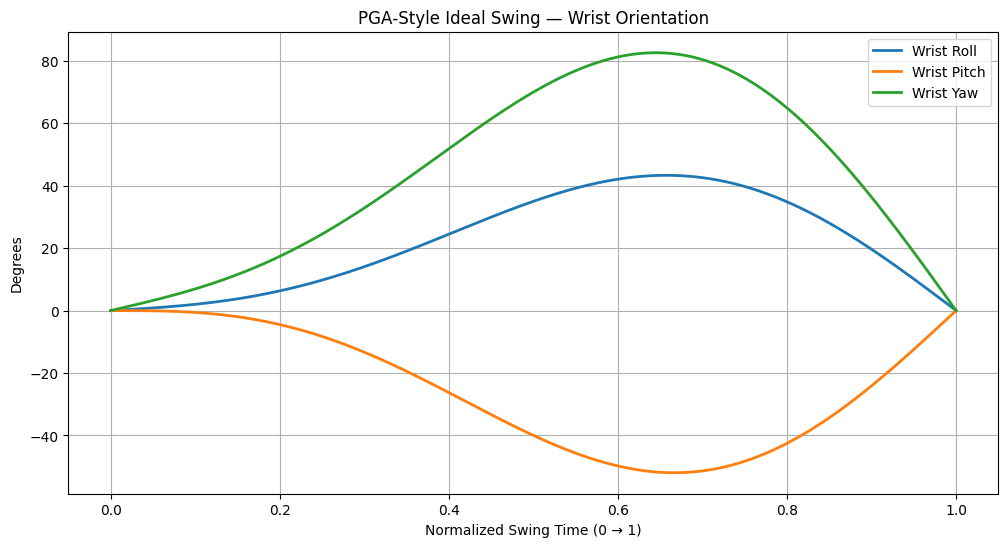

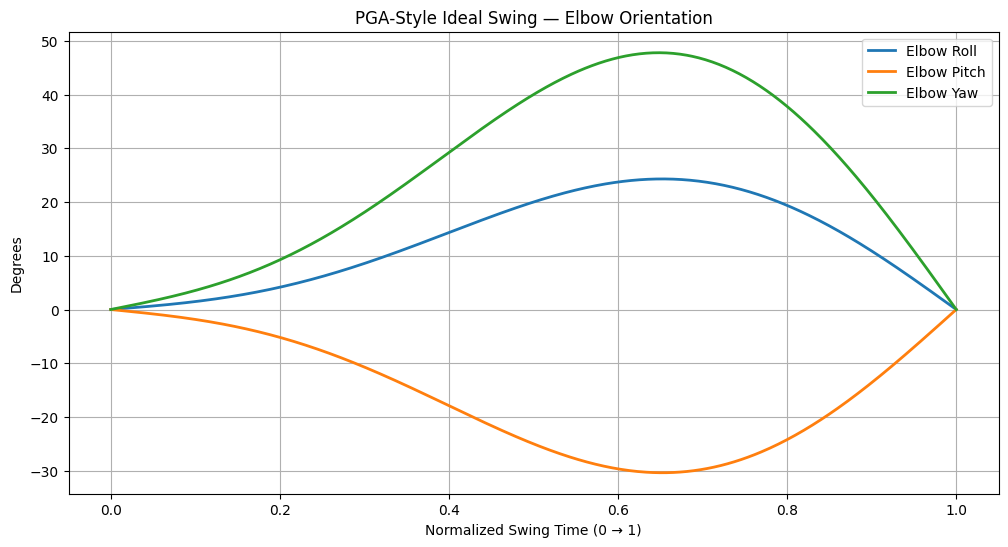

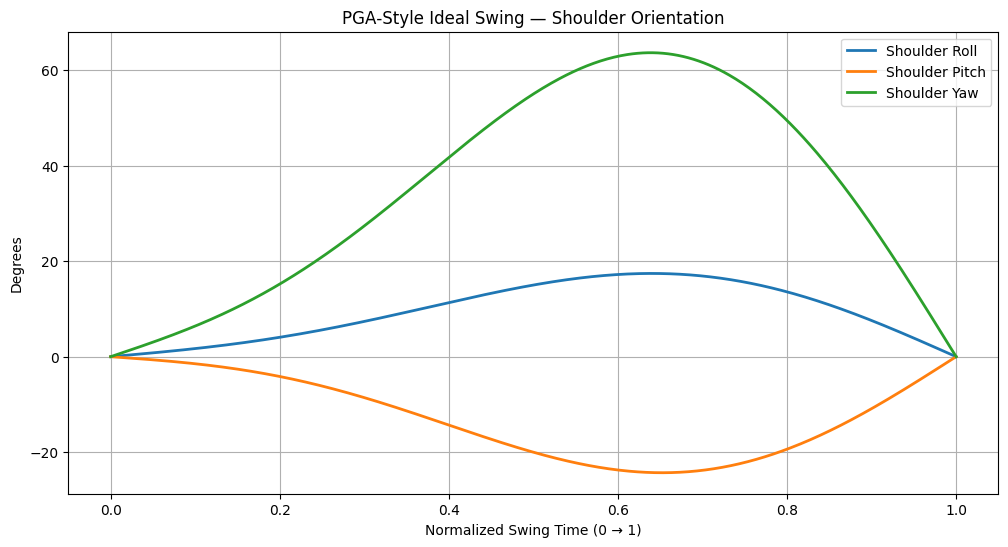

In [37]:
# Normalized time axis (0 → 1)
t = np.linspace(0, 1, 500)

# --- PGA-STYLE IDEAL CURVES FOR EACH JOINT ---

# Wrist: most rotation, fastest changes
ideal_wrist_roll  =  35*np.sin(np.pi * t) - 15*np.sin(2*np.pi*t)
ideal_wrist_pitch = -40*np.sin(np.pi * t) + 20*np.sin(2*np.pi*t)
ideal_wrist_yaw   =  70*np.sin(np.pi * t) - 25*np.sin(2*np.pi*t)

# Elbow: moderate rotation, smoother transitions
ideal_elbow_roll  =  20*np.sin(np.pi * t) - 8*np.sin(2*np.pi*t)
ideal_elbow_pitch = -25*np.sin(np.pi * t) + 10*np.sin(2*np.pi*t)
ideal_elbow_yaw   =  40*np.sin(np.pi * t) - 15*np.sin(2*np.pi*t)

# Shoulder: biggest, smoothest arcs (controls plane + depth)
ideal_shoulder_roll  =  15*np.sin(np.pi * t) - 5*np.sin(2*np.pi*t)
ideal_shoulder_pitch = -20*np.sin(np.pi * t) + 8*np.sin(2*np.pi*t)
ideal_shoulder_yaw   =  55*np.sin(np.pi * t) - 18*np.sin(2*np.pi*t)

# --- PLOTTING FUNCTION ---
def plot_ideal_joint(t, roll, pitch, yaw, name):
    plt.figure(figsize=(12,6))
    plt.plot(t, roll,  label=f"{name} Roll",  linewidth=2)
    plt.plot(t, pitch, label=f"{name} Pitch", linewidth=2)
    plt.plot(t, yaw,   label=f"{name} Yaw",   linewidth=2)
    plt.title(f"PGA‑Style Ideal Swing — {name} Orientation")
    plt.xlabel("Normalized Swing Time (0 → 1)")
    plt.ylabel("Degrees")
    plt.grid(True)
    plt.legend()
    plt.show()

# --- GENERATE ALL THREE GRAPHS ---
plot_ideal_joint(t, ideal_wrist_roll,   ideal_wrist_pitch,   ideal_wrist_yaw,   "Wrist")
plot_ideal_joint(t, ideal_elbow_roll,   ideal_elbow_pitch,   ideal_elbow_yaw,   "Elbow")
plot_ideal_joint(t, ideal_shoulder_roll, ideal_shoulder_pitch, ideal_shoulder_yaw, "Shoulder")
